In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from datetime import datetime

In [13]:
df = pd.read_csv("Customer Behavior.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [23]:
df.head()

,Customer_ID,Purchase_Date,Product_Category,Product_Price,Quantity,Total_Purchase_Amount,Payment_Method,Customer_Age,Returns,Customer_Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer_ID            250000 non-null  int64         
 1   Purchase_Date          250000 non-null  datetime64[ns]
 2   Product_Category       250000 non-null  object        
 3   Product_Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total_Purchase_Amount  250000 non-null  int64         
 6   Payment_Method         250000 non-null  object        
 7   Customer_Age           250000 non-null  int64         
 8   Returns                202404 non-null  float64       
 9   Customer_Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

In [25]:
df.shape

(250000, 13)

In [26]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

print(df.columns)

Index(['Customer_ID', 'Purchase_Date', 'Product_Category', 'Product_Price',
       'Quantity', 'Total_Purchase_Amount', 'Payment_Method', 'Customer_Age',
       'Returns', 'Customer_Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


In [27]:
df.isnull().sum()

,0
Customer_ID,0
Purchase_Date,0
Product_Category,0
Product_Price,0
Quantity,0
Total_Purchase_Amount,0
Payment_Method,0
Customer_Age,0
Returns,47596
Customer_Name,0


In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

In [30]:
df.describe()

,Customer_ID,Purchase_Date,Product_Price,Quantity,Total_Purchase_Amount,Customer_Age,Returns,Age,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622


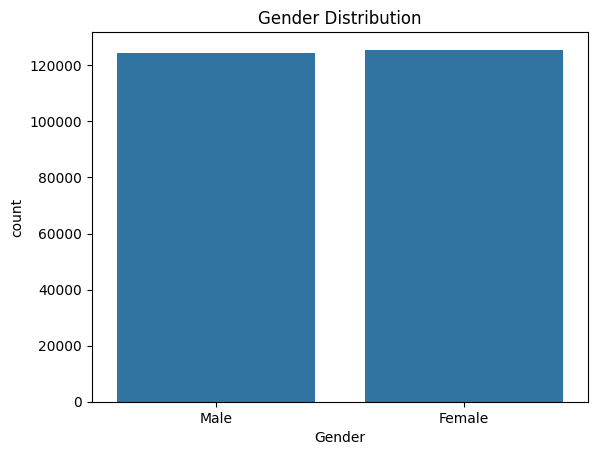

In [31]:
sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')
plt.show()

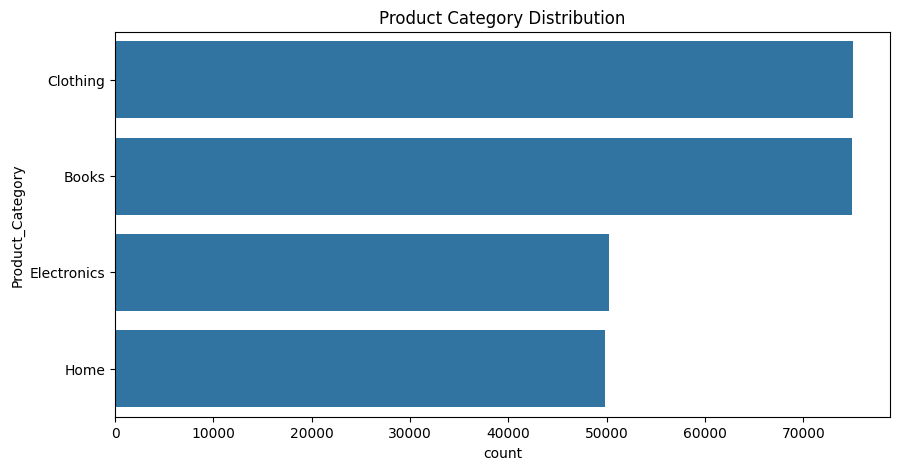

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='Product_Category',
    data=df,
    order=df['Product_Category'].value_counts().index
)

plt.title('Product Category Distribution')
plt.show()

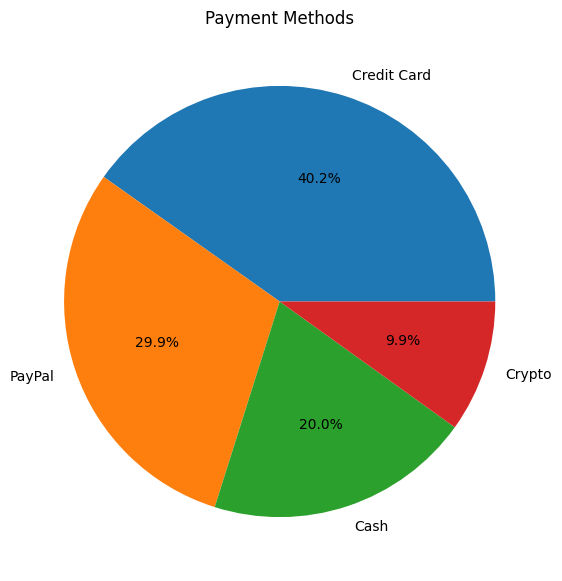

In [34]:
df['Payment_Method'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Payment Methods')
plt.ylabel('')
plt.show()

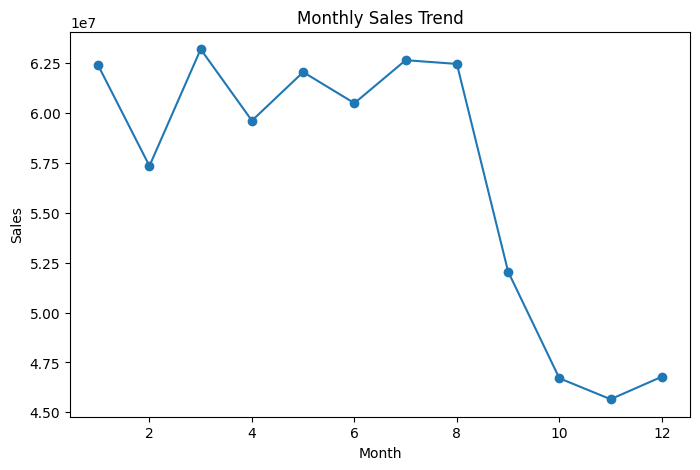

In [35]:
df['Month'] = df['Purchase_Date'].dt.month

monthly_sales = df.groupby('Month')['Total_Purchase_Amount'].sum()

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

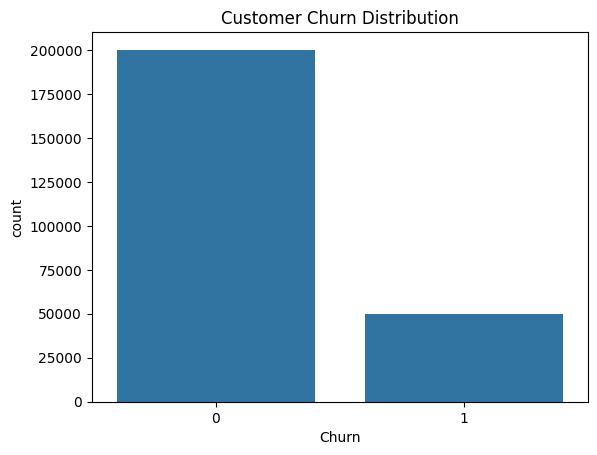

In [36]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

In [37]:
customer_data = df.groupby('Customer_ID').agg({
    'Purchase_Date': lambda x: (df['Purchase_Date'].max() - x.max()).days,
    'Customer_ID': 'count',
    'Total_Purchase_Amount': 'sum',
    'Quantity': 'sum',
    'Age': 'first',
    'Churn': 'first'
})

In [38]:
customer_data.columns = [
    'Recency',
    'Frequency',
    'Monetary',
    'Total_Quantity',
    'Age',
    'Churn'
]

customer_data.head()

,Recency,Frequency,Monetary,Total_Quantity,Age,Churn
Customer_ID,,,,,,
1,57,1,3491,5,70,0
2,298,3,7988,8,27,0
3,88,8,22587,23,23,0
4,126,4,8715,9,66,1
5,170,8,12524,33,26,0


In [39]:
customer_data['R_Score'] = pd.qcut(
    customer_data['Recency'],
    4,
    labels=[4,3,2,1]
)

customer_data['F_Score'] = pd.qcut(
    customer_data['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

customer_data['M_Score'] = pd.qcut(
    customer_data['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [40]:
customer_data['RFM_Score'] = (
    customer_data['R_Score'].astype(str) +
    customer_data['F_Score'].astype(str) +
    customer_data['M_Score'].astype(str)
)

In [41]:
def customer_segment(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['F_Score'] == 4:
        return 'Loyal Customers'

    elif row['R_Score'] == 1:
        return 'At Risk'

    elif row['M_Score'] == 4:
        return 'Big Spenders'

    else:
        return 'Regular Customers'

In [42]:
customer_data['Segment'] = customer_data.apply(
    customer_segment,
    axis=1
)

In [43]:
customer_data['Segment'].value_counts()

,count
Segment,
Regular Customers,23367
At Risk,11345
Loyal Customers,8803
Champions,3615
Big Spenders,2543


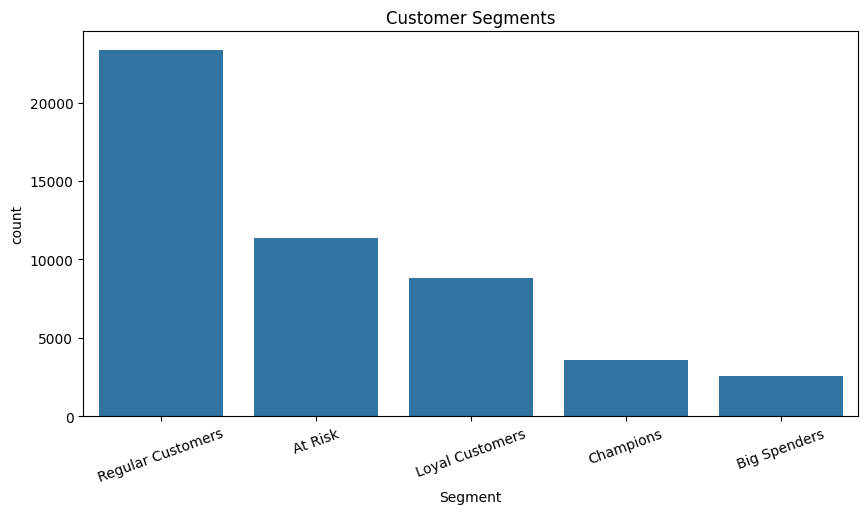

In [44]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Segment',
    data=customer_data,
    order=customer_data['Segment'].value_counts().index
)

plt.title('Customer Segments')
plt.xticks(rotation=20)
plt.show()

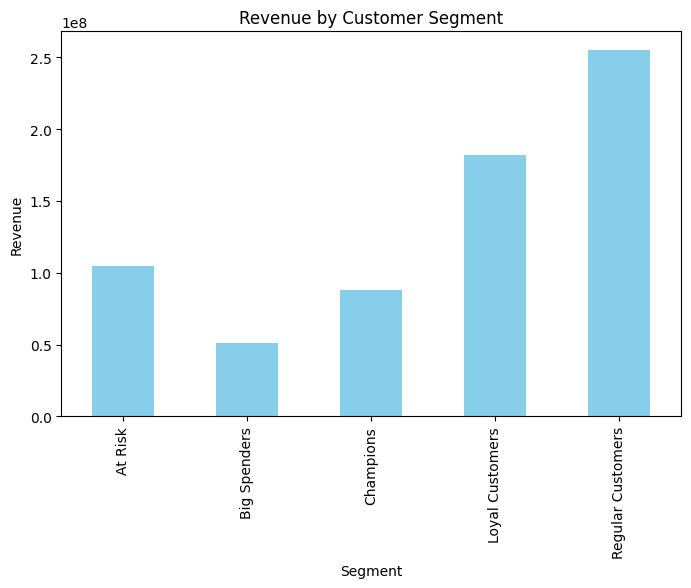

In [45]:
segment_revenue = customer_data.groupby('Segment')['Monetary'].sum()

segment_revenue.plot(
    kind='bar',
    figsize=(8,5),
    color='skyblue'
)

plt.title('Revenue by Customer Segment')
plt.ylabel('Revenue')
plt.show()

In [46]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(churn_rate)

Churn
0    80.0504
1    19.9496
Name: proportion, dtype: float64


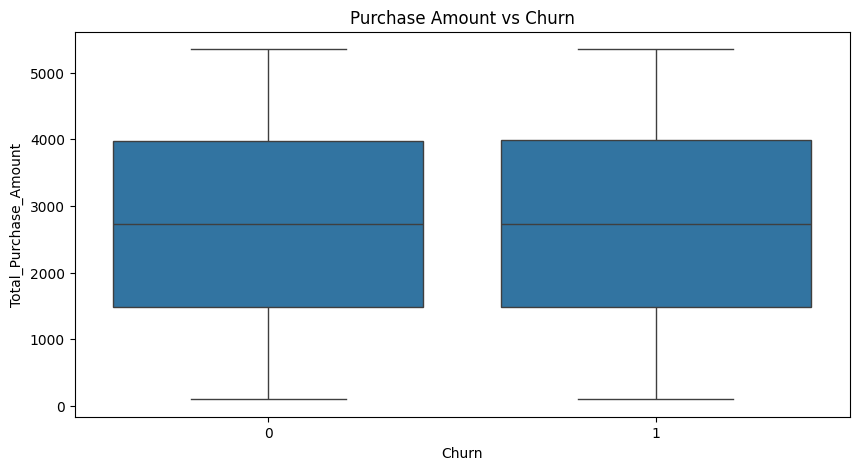

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Churn',
    y='Total_Purchase_Amount',
    data=df
)

plt.title('Purchase Amount vs Churn')
plt.show()

In [48]:
features = customer_data[
    ['Recency', 'Frequency', 'Monetary']
]

In [49]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

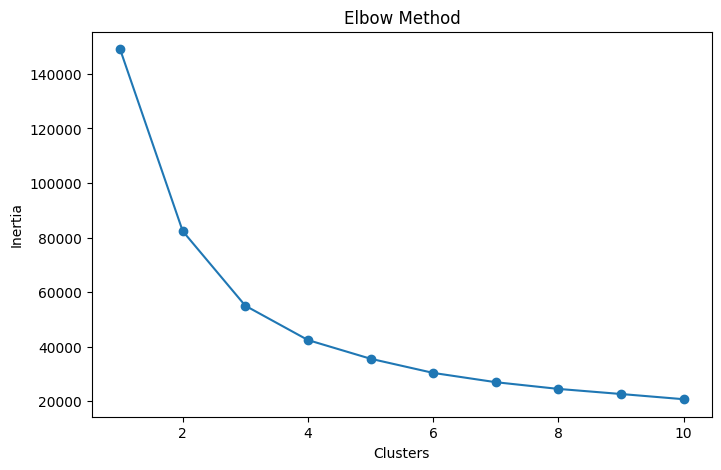

In [50]:
inertia = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.show()

In [51]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_data['Cluster'] = kmeans.fit_predict(
    scaled_features
)

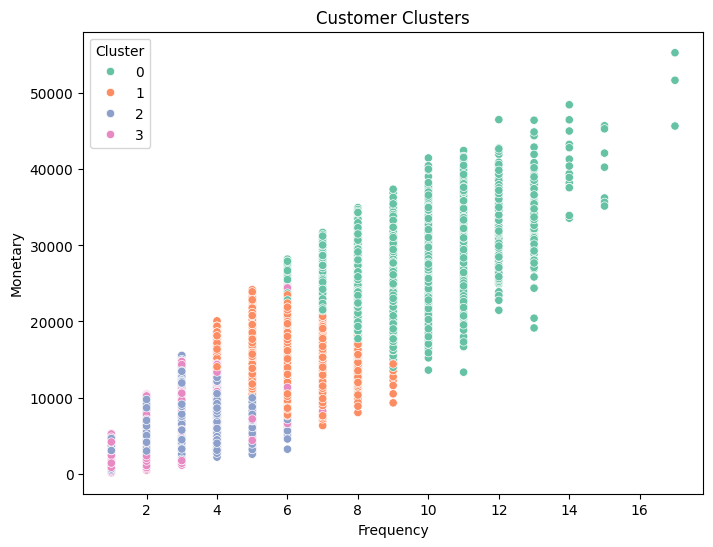

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=customer_data,
    palette='Set2'
)

plt.title('Customer Clusters')
plt.show()

In [53]:
repeat_customers = (
    customer_data['Frequency'] > 1
).mean() * 100

print("Repeat Customer Rate:", repeat_customers)

Repeat Customer Rate: 96.60781511082479


In [55]:
customer_data.to_csv(
    'customer_segments.csv',
    index=False
)